In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df = pd.read_csv("bollywood.csv")
df.head(10)

,SlNo,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
0,1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
1,2,4-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
2,3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
3,4,4-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
4,5,4-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224
5,6,30-May-14,Citylights,HS,Drama,7,35.00,1076591,1806,84
6,7,19-Sep-14,Daawat-E-Ishq,N,Comedy,30,24.60,3905050,8315,1373
7,8,11-Jan-13,Matru Ki Bijlee Ka Mandola,N,Comedy,33,40.00,2435283,4326,647
8,9,10-Jan-14,Dedh Ishqiya,LW,Comedy,31,27.00,2333067,2436,591
9,10,11-Jan-13,Gangoobai,N,Drama,2,0.01,4354,1,1


<Figure size 640x480 with 0 Axes>

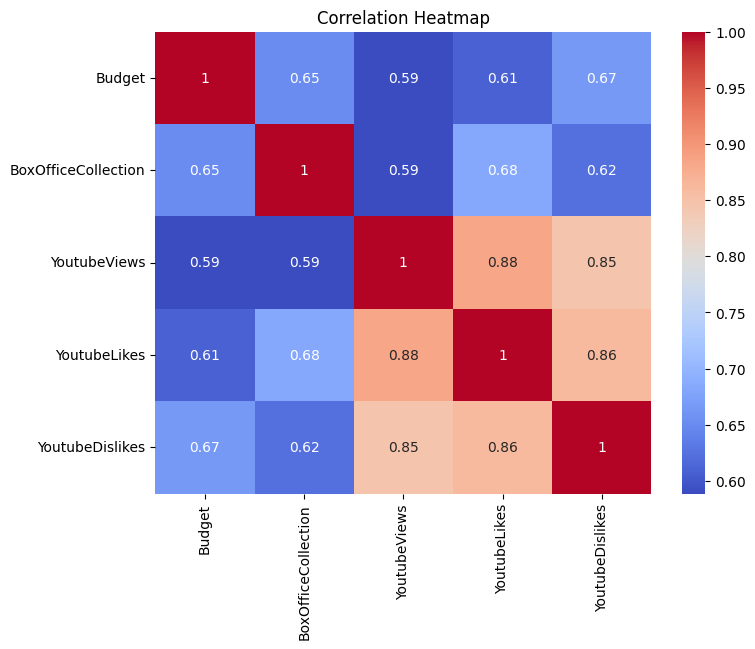

In [ ]:
#1
df.info()
#2
genere_cnt=df['Genre'].value_counts()
genere_cnt
#3
genre_release_crosstab = pd.crosstab(df['Genre'], df['ReleaseTime'])
genre_release_crosstab
#4
df['ReleaseDate'] = pd.to_datetime(df['ReleaseDate'])
df['Month'] = df['ReleaseDate'].dt.month

month_count = df['Month'].value_counts().sort_index()
month_count

month_count.idxmax()
#5
high_budget = df[df['Budget'] >= 25]
high_budget_month = high_budget['Month'].value_counts().sort_index()
high_budget_month
high_budget_month.idxmax()
#6
df['ROI'] = (df['BoxOfficeCollection'] - df['Budget']) / df['Budget']

top10_roi = df[['MovieName', 'ROI']].sort_values(by='ROI', ascending=False).head(10)
top10_roi
#7
avg_roi_release = df.groupby('ReleaseTime')['ROI'].mean()
avg_roi_release
#8
plt.figure()
plt.hist(df['Budget'], bins=20)
plt.title("Histogram of Movie Budgets")
plt.xlabel("Budget")
plt.ylabel("Frequency")

sns.kdeplot(df['Budget'], fill=True)
plt.title("Distribution of Movie Budgets")
plt.show()
plt.show()

#9
roi_compare = df[df['Genre'].isin(['Comedy', 'Drama'])]

plt.figure()
sns.boxplot(x='Genre', y='ROI', data=roi_compare)
#10
corr = df['BoxOfficeCollection'].corr(df['YoutubeLikes'])
corr
#11
plt.figure(figsize=(10,5))
sns.boxplot(x='Genre', y='YoutubeLikes', data=df)
plt.xticks(rotation=45)
plt.title("YouTube Likes by Genre")
plt.show()
#12
corr_vars = df[['Budget', 'BoxOfficeCollection',
                'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']]

plt.figure(figsize=(8,6))
sns.heatmap(corr_vars.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


